In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'C:\Users\Marcus\Desktop\python pandas\superstore_data\version_control\superstore_clean.csv')
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,31518,CA-2012-169397,2012-12-24,2013-01-09,First Class,JB-15925,Joni Blumstein,Consumer,Dublin,Ohio,...,OFF-BI-10002852,Office Supplies,Binders,Ibico Standard Transparent Covers,19.7760,4,0.70,-13.84,0.79,Medium
1,6224,US-2011-144729,2011-07-21,2011-08-07,First Class,SS-20140,Saphhira Shifley,Corporate,San Miguelito,Panama,...,OFF-FA-10002247,Office Supplies,Fasteners,"Oic Paper Clips, Bulk Pack",11.5440,2,0.40,-5.22,0.97,Medium
2,15333,IT-2014-4749412,2014-09-18,2014-09-28,Standard Class,MB-18085,Mick Brown,Unknown,Birmingham,England,...,OFF-AR-10003113,Office Supplies,Art,"Binney & Smith Pens, Blue",29.8500,5,0.50,-4.80,3.71,Medium
3,49259,NI-2013-4420,2013-04-10,2013-10-26,Standard Class,MP-7965,Michael Paige,Corporate,Lagos,Lagos,...,OFF-AVE-10004512,Office Supplies,Binders,"Avery Hole Reinforcements, Economy",1.3230,1,0.70,-3.09,0.06,Medium
4,24199,IN-2014-14423,2014-10-29,2014-11-27,First Class,DL-12925,Daniel Lacy,Consumer,Kendari,Sulawesi Tenggara,...,FUR-FU-10002362,Furnitures,Furnishings,"Advantus Door Stop, Black",131.4876,4,0.27,25.17,0.00,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51365,17526,ES-2014-2057259,2014-08-02,2014-05-19,First Class,PB-19150,Philip Brown,Consumer,Cagnes-Sur-Mer,Provence-Alpes-Cote D'Azur,...,OFF-PA-10002616,Office Supplies,Paper,"Green Bar Parchment Paper, Multicolor",108.5400,6,0.00,34.56,11.76,Medium
51366,36055,CA-2011-121573,2011-11-03,2011-08-07,Standard Class,SG-20605,Speros Goranitis,Consumer,New York City,New York,...,TEC-PH-10000984,Technology,Phones,Panasonic Kx-Tg9471B,783.9600,4,0.00,219.51,64.42,High
51367,43576,TU-2011-9190,2011-12-23,2012-01-11,Second Class,CM-1830,Cari Macintyre,Corporate,Corum,Corum,...,OFF-KIT-10002357,Office Supplies,Appliances,"Kitchenaid Blender, White",39.8400,1,0.60,-12.96,5.84,Medium
51368,22403,IN-2013-35388,2013-08-07,2013-11-19,Standard Class,IM-15055,Unknown,Consumer,Jakarta,Jakarta,...,OFF-AR-10000058,Office Supplies,Art,"Stanley Canvas, Water Color",38.4345,1,0.27,3.66,2.96,Medium


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51370 entries, 0 to 51369
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51370 non-null  int64  
 1   Order ID        51370 non-null  str    
 2   Order Date      51370 non-null  str    
 3   Ship Date       51370 non-null  str    
 4   Ship Mode       51370 non-null  str    
 5   Customer ID     51370 non-null  str    
 6   Customer Name   51336 non-null  str    
 7   Segment         51370 non-null  str    
 8   City            51351 non-null  str    
 9   State           51339 non-null  str    
 10  Country         51370 non-null  str    
 11  Postal Code     51370 non-null  int64  
 12  Market          51370 non-null  str    
 13  Region          51370 non-null  str    
 14  Product ID      51370 non-null  str    
 15  Category        51370 non-null  str    
 16  Sub-Category    51370 non-null  str    
 17  Product Name    51370 non-null  str    
 1

In [4]:
# Which product Categories and Sub-Categories are the top revenue drivers versus the top profit leaks?

In [5]:
cat_subcat_profit = df.groupby([df['Category'],df['Sub-Category']])[['Profit']].agg(
    total_profit = ('Profit','sum'),
    average_profit = ('Profit','mean')
).round(2)
cat_subcat_profit

total_profit  average_profit
Category        Sub-Category                              
Furnitures      Bookcases        162233.83           68.17
                Chairs           140003.65           41.45
                Furnishings       46838.73           14.89
                Tables           -61621.47          -72.58
                Unknown            -969.18           -6.92
Office Supplies Appliances       139199.92           80.42
                Art               57365.68           11.89
                Binders           70919.23           11.70
                Envelopes         29246.83           12.21
                Fasteners         11388.77            4.77
                Labels            14885.51            5.81
                Paper             58375.59           16.70
                Storage          105829.47           21.20
                Supplies          22301.37            9.30
                Unknown            9796.66           20.93
Technology      Accessories      128740.82           42.36
                Copiers          255263.41          116.56
                Machines          58609.99           40.06
                Phones           213934.86           64.65
                Unknown            8251.88           51.25

In [6]:
cat_subcat_profit.reset_index(inplace=True)

In [7]:
cat_subcat_profit.sort_values(by='total_profit', ascending=False)

,Category,Sub-Category,total_profit,average_profit
16,Technology,Copiers,255263.41,116.56
18,Technology,Phones,213934.86,64.65
0,Furnitures,Bookcases,162233.83,68.17
1,Furnitures,Chairs,140003.65,41.45
5,Office Supplies,Appliances,139199.92,80.42
15,Technology,Accessories,128740.82,42.36
12,Office Supplies,Storage,105829.47,21.20
7,Office Supplies,Binders,70919.23,11.70
17,Technology,Machines,58609.99,40.06
11,Office Supplies,Paper,58375.59,16.70


In [8]:
cat_subcat_profit = cat_subcat_profit.sort_values(by='total_profit', ascending=False)

In [9]:
cat_subcat_profit.reset_index(inplace=True)

In [10]:
cat_subcat_profit

,index,Category,Sub-Category,total_profit,average_profit
0,16,Technology,Copiers,255263.41,116.56
1,18,Technology,Phones,213934.86,64.65
2,0,Furnitures,Bookcases,162233.83,68.17
3,1,Furnitures,Chairs,140003.65,41.45
4,5,Office Supplies,Appliances,139199.92,80.42
5,15,Technology,Accessories,128740.82,42.36
6,12,Office Supplies,Storage,105829.47,21.20
7,7,Office Supplies,Binders,70919.23,11.70
8,17,Technology,Machines,58609.99,40.06
9,11,Office Supplies,Paper,58375.59,16.70


In [11]:
# Which product Categories and Sub-Categories are the top revenue drivers versus the top profit leaks?

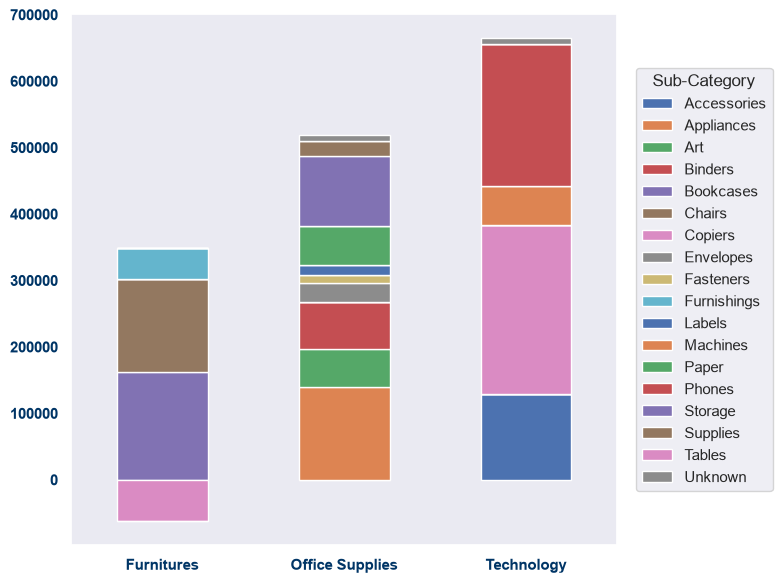

In [16]:
sns.set_theme()
pivot_df = cat_subcat_profit.pivot(index='Category', columns='Sub-Category', values='total_profit').fillna(0)

fig, ax = plt.subplots(figsize=(8, 6))
pivot_df.plot(kind='bar', stacked=True, ax=ax)

sns.color_palette("light:#5A9", as_cmap=True)
plt.grid(False)
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=0, fontweight='bold')
plt.yticks(fontweight='bold')
ax.tick_params(axis='x', labelcolor='#003566')
ax.tick_params(axis='y', labelcolor='#003566')

sns.move_legend(ax, loc='center left', bbox_to_anchor=(1.02, 0.5), title='Sub-Category')
plt.tight_layout()
plt.show()

In [ ]:
# Business Question 5:
# Which product Categories and Sub-Categories are the top revenue drivers versus the top profit leaks?

# Answer:
# Technology tops the overall revenue stream with Copiers as the main driver of gains with around $250k. Phones became the second top choice with
# with around $210k. Tables as part of Furnitures hit a massive loss of $60k.